### Calculating the board

In [1]:
from ultralytics import YOLO
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from utils import *

In [2]:
model_board = YOLO("../code/runs/segment/train6/weights/best.pt")

In [3]:
test_image_path = "../code/captured_images/image_178.jpg"

In [4]:
result = model_board.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_178.jpg: 480x640 1 Board, 2 White_starts, 59.7ms
Speed: 2.1ms preprocess, 59.7ms inference, 23.1ms postprocess per image at shape (1, 3, 480, 640)


In [5]:
model_pieces = YOLO("../code/Training/runs/detect/train6/weights/best.pt")

In [6]:
result_pieces = model_pieces.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_178.jpg: 480x640 2 BBs, 1 BK, 1 BKN, 7 BPs, 1 BQ, 2 BRs, 2 WBs, 1 WK, 1 WKN, 7 WPs, 1 WQ, 2 WRs, 31.3ms
Speed: 0.6ms preprocess, 31.3ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


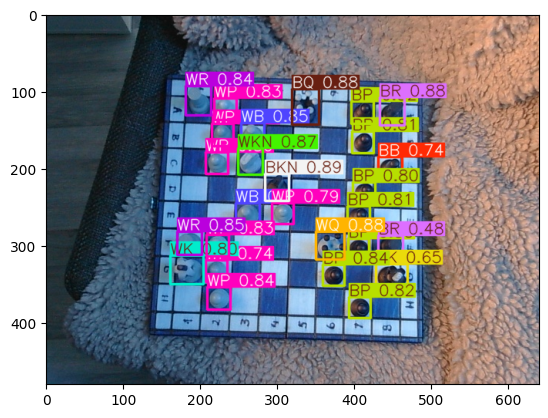

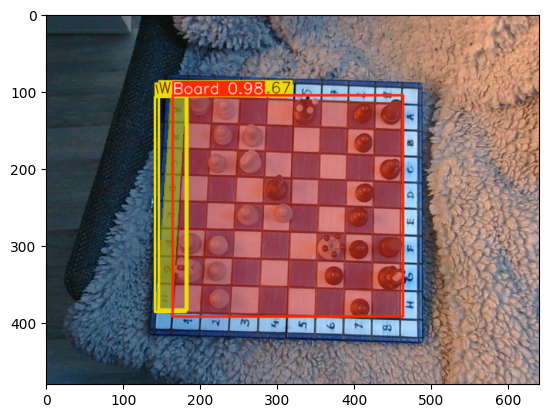

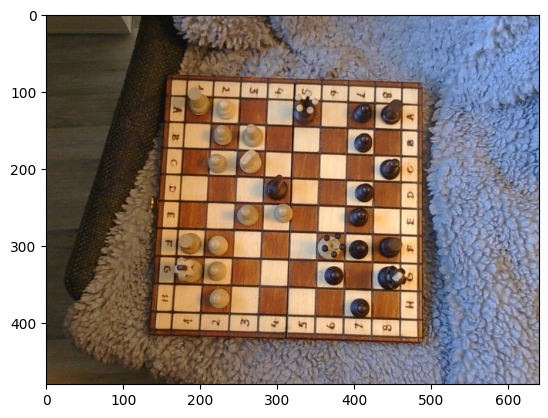

In [13]:
plt.imshow(result_pieces[0].plot())
plt.show()

plt.imshow(result[0].plot())
plt.show()


image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()


In [9]:
transformed_positions = list()
lower_y_coord = 10 #How many pixels lower from midpoint of the bounding box
H = calculate_homography(result,test_image_path)
image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.warpPerspective(image,H,(480,480))



for box in result_pieces[0].boxes.xywh:
    x,y,_,h = box.cpu()
    piece_pos = cv2.perspectiveTransform(np.array([[[x,y+h/2-lower_y_coord]]]), H).squeeze()
    transformed_positions.append(piece_pos)

transformed_positions = np.array(transformed_positions)


w,h = image.shape[0:2]

x = (np.linspace(0,w,9)+(w/16))[:-1]
y = (np.linspace(0,h,9)+(h/16))[:-1]


X,Y = np.meshgrid(x,y) #Define the middle points of the square

square_middles = np.stack([X.flatten(),Y.flatten()],axis=1)



diff = transformed_positions[:, None, :] - square_middles[None, :, :]




distances = np.linalg.norm(diff,axis=2)
idx = np.argmin(distances, axis=1)

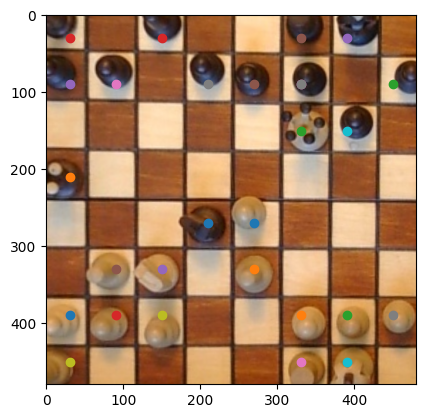

In [10]:
plt.imshow(image)

for box in square_middles[idx]:

    plt.scatter(box[0],box[1])

In [11]:
fen = create_fen(result_pieces,idx)
fen

'r1b2rk1/pp1ppb1p/5Qp1/q7/3nP3/1BN1B3/PPP2PPP/R4RK1 w - - 0 1'

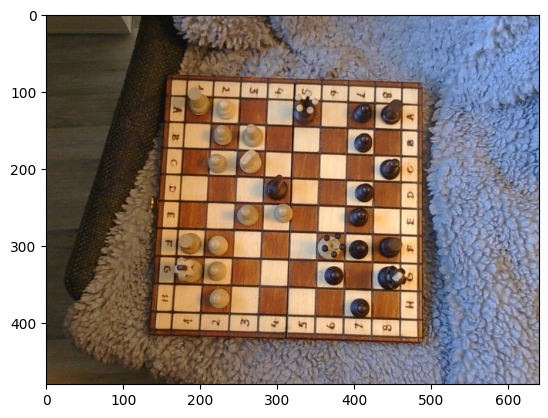

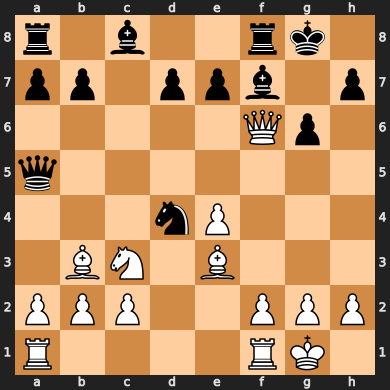

In [12]:
import chess
board = chess.Board(fen)
image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()
board